In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Exploratory Data Analysis (EDA)
This notebook provides a comprehensive exploratory data analysis of the Reto_data dataset.

## Table of Contents
1. Data Loading
2. Data Overview
3. Data Quality Assessment
4. Statistical Summary
5. Distribution Analysis
6. Correlation Analysis
7. Missing Values Analysis
8. Outlier Detection
9. Key Insights and Conclusions

## 1. Data Loading

In [7]:
# Load the dataset
# Using fastparquet as an alternative engine to avoid pyarrow compatibility issues
df = pd.read_parquet("../data/reto.parquet", engine='fastparquet')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset loaded successfully!
Shape: 4795 rows × 72 columns


,id,attachments,author,authorCategory,authorCategoryId,authorId,authorURL,automateProjectId,caption,context,...,sourceLimitations,sourceName,sourceURL,tags,text,threadId,title,type,url,youtubeChannelId
0,c6adb4630994bdee807d387382d526bc,[],Consulta Popular,,,,,,,El camino hacia la consulta popular en Colombia,...,[],,https://www.proclamadelpacifico.com/el-camino-...,[],Hasta 1990 el C&oacute;digo Sustantivo del Tra...,c6f5b8840e9675c607bc42a16543c1d72ef4f771759834...,El camino hacia la consulta popular en Colombia,ar,https://www.proclamadelpacifico.com/el-camino-...,
1,9fee3686bd7f2fd45d381a9b388dfb5e,[],Consulta Popular,,,,,,,La Consulta popular constituyente,...,[],,https://www.proclamadelpacifico.com/la-consult...,[],La Consulta popular constituyente/El deliberad...,f565efdfc7bd00275467b1e2d8e90036f986e5e50d1896...,La Consulta popular constituyente,ar,https://www.proclamadelpacifico.com/la-consult...,
2,9adb9324d96a398905767afcf428e956,[],Daniel Hernandez,,,,,,,"Empleo juvenil, frente del mercado laboral que...",...,[],,https://www.portafolio.co/economia/empleo/refo...,[],En medio de la expectativa por lo que vendr&aa...,3d97a4b17c73e05726d2a10e10edf6a653cfa03053e7ca...,"Empleo juvenil, frente del mercado laboral que...",ar,https://www.portafolio.co/economia/empleo/refo...,
3,be6ed61346de9fc96e3e797d70d275a9,[],,,,,,,,Petro da marcha atrás con consulta sobre <q>re...,...,[],,https://www.eleconomista.com.mx/internacionale...,[],El Senado tampoco autoriz&oacute; a mediados d...,1e19407566ce89c0a86e50c86633f8ccf07ccfdb9e60c2...,Petro da marcha atr&aacute;s con consulta sobr...,ar,https://www.eleconomista.com.mx/internacionale...,
4,4a893f2667aa8eddb4c84fcd09fcd43f,[],,,,,,,,Petro firmó decreto de la <q>reforma</q> <q>la...,...,[],,https://www.kienyke.com/politica/gustavo-petro...,[],Cr&eacute;ditos: X @infopresidencia El preside...,f689aa9604212e6e350dbfb942bc3579f07871b5f8b547...,Petro firm&oacute; decreto de la <q>reforma</q...,ar,https://www.kienyke.com/politica/gustavo-petro...,
5,2e5c49480d99a865a7764dc0fb25ede4,[],,,,,,,,<q>Reforma</q> <q>Laboral</q>: Petro 5 – Uribe 0,...,[],,https://blogs.elespectador.com/actualidad/cura...,[],&ldquo;Si una sociedad libre no puede ayudar a...,c9878007344ba51a205c5fa0499d860252d8b1ba3cf301...,&nbsp;<q>Reforma</q> <q>Laboral</q>: Petro 5 &...,ar,https://blogs.elespectador.com/actualidad/cura...,
6,e99bda8e3a1791b3b9a12cb18c50216e,[],,,,,,,,"\n Recargos dominicales, jornadas y con...",...,[],,https://www.noticiascaracol.com/economia/recar...,[],Publicidad Publicidad Luego de un vertiginoso ...,57dde06c8a6fd2b3124a77a7a231f2aa29114cbf789c2c...,"Recargos dominicales, jornadas y contratos: &i...",ar,https://www.noticiascaracol.com/economia/recar...,
7,12bd48cdcb32a9c1652e24d6e0a62ff,[],Magalí Schefer,,,,,,,Es oficial: Gustavo Petro deroga el decreto co...,...,[],,https://www.cronista.com/colombia/actualidad-c...,[],El Gobierno colombiano deroga la convocatoria ...,1472d41f55494522577a403dd98d4bd1d8927f055fe587...,Es oficial: Gustavo Petro deroga el decreto co...,ar,https://www.cronista.com/colombia/actualidad-c...,
8,70cc693b0b395b7a8fea649ba0d22c10,[],EFE,,,,,,,Petro firma la ley de la <q>reforma</q> <q>lab...,...,[],,https://proceso.hn/petro-firma-la-ley-de-la-re...,[],Bogot&aacute; &ndash; El presidente colombiano...,b70119bcb0c4038d25d7c9d48a7e64adfb9072668355c0...,Petro firma la ley de la <q>reforma</q> <q>lab...,ar,https://proceso.hn/petro-firma-la-ley-de-la-re...,
9,57c1c2457019826ae9e12193d470a6e3,[],Maria José Castro,,,,,,,<q>Reforma</q> <q>laboral</q>: MinTrabajo expl...,...,[],,https://caracol.com.co/2025/06/25/reforma-labo...,[],El Ministro de Trabajo Antonio Sanguino afirm&...,b45f84b1a9de81a164e94fa19662bf1a92e6782686adec...,<q>Reforma</q> <q>laboral</q>: MinTrabajo expl...,ar,https://caracol.com.co/2025/06/25/reforma-labo...,


## 2. Data Overview

In [8]:
# Basic information about the dataset
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
df.info()
print("\n" + "=" * 80)
print("COLUMN NAMES")
print("=" * 80)
print(df.columns.tolist())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4795 entries, 0 to 4794
Data columns (total 72 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   id                            4795 non-null   object
 1   attachments                   4795 non-null   object
 2   author                        4795 non-null   object
 3   authorCategory                4795 non-null   object
 4   authorCategoryId              4795 non-null   object
 5   authorId                      4795 non-null   object
 6   authorURL                     4795 non-null   object
 7   automateProjectId             4795 non-null   object
 8   caption                       4795 non-null   object
 9   context                       4795 non-null   object
 10  contextTitle                  4795 non-null   object
 11  country                       4795 non-null   object
 12  createdAt                     4795 non-null   object
 13

In [9]:
# Data types summary
print("=" * 80)
print("DATA TYPES SUMMARY")
print("=" * 80)
dtype_counts = df.dtypes.value_counts()
print(dtype_counts)
print(f"\nNumerical columns: {df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"\nCategorical/Object columns: {df.select_dtypes(include=['object', 'category']).columns.tolist()}")
print(f"\nDatetime columns: {df.select_dtypes(include=['datetime64']).columns.tolist()}")

DATA TYPES SUMMARY
object    72
Name: count, dtype: int64

Numerical columns: []

Categorical/Object columns: ['id', 'attachments', 'author', 'authorCategory', 'authorCategoryId', 'authorId', 'authorURL', 'automateProjectId', 'caption', 'context', 'contextTitle', 'country', 'createdAt', 'description', 'engagementRate', 'facebookAdAccountId', 'facebookIds', 'facebookMessengerThreadId', 'facebookPageId', 'group', 'hasImageOrVideo', 'host', 'ignored', 'image', 'influenceScore', 'initialAuthor', 'internalId', 'isAdvertisement', 'isAffectedByPermissionsIssue', 'isArchived', 'isBot', 'isComment', 'isDeleted', 'isHidden', 'isRead', 'isReplied', 'isRepliedPriv', 'isRetweet', 'keywords', 'language', 'latitude', 'liked', 'link', 'longitude', 'maxRating', 'media', 'metaTitle', 'metadata', 'minRating', 'parentCreatedAt', 'parentId', 'parentText', 'places', 'preciseId', 'private', 'rating', 'recipients', 'sentiment', 'sex', 'socialType', 'sourceData', 'sourceId', 'sourceLimitations', 'sourceName', 

## 3. Data Quality Assessment

In [10]:
# Missing values analysis (including empty strings)
print("=" * 80)
print("MISSING VALUES ANALYSIS (Including Empty Strings)")
print("=" * 80)

# Count null values
null_counts = df.isnull().sum()

# Count empty strings for object columns
empty_string_counts = pd.Series(0, index=df.columns)
for col in df.select_dtypes(include=['object']).columns:
    empty_string_counts[col] = (df[col].str.strip() == '').sum()

# Combined missing data
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Null_Count': null_counts,
    'Empty_String_Count': empty_string_counts,
    'Total_Missing': null_counts + empty_string_counts,
    'Missing_Percentage': ((null_counts + empty_string_counts) / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total_Missing'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_data) > 0:
    print(f"\nColumns with missing data (null or empty strings):")
    display(missing_data)
    
    print(f"\nSummary:")
    print(f"  Total columns with missing data: {len(missing_data)}")
    print(f"  Total null values: {null_counts.sum():,}")
    print(f"  Total empty strings: {empty_string_counts.sum():,}")
    print(f"  Combined missing values: {missing_data['Total_Missing'].sum():,}")
else:
    print("✓ No missing values or empty strings found in the dataset!")

MISSING VALUES ANALYSIS (Including Empty Strings)

Columns with missing data (null or empty strings):


,Column,Null_Count,Empty_String_Count,Total_Missing,Missing_Percentage
rating,rating,0,4795,4795,100.00
facebookMessengerThreadId,facebookMessengerThreadId,0,4795,4795,100.00
initialAuthor,initialAuthor,0,4795,4795,100.00
facebookAdAccountId,facebookAdAccountId,0,4795,4795,100.00
automateProjectId,automateProjectId,0,4795,4795,100.00
youtubeChannelId,youtubeChannelId,0,4795,4795,100.00
sourceData,sourceData,0,4795,4795,100.00
metadata,metadata,0,4795,4795,100.00
maxRating,maxRating,0,4795,4795,100.00
minRating,minRating,0,4795,4795,100.00



Summary:
  Total columns with missing data: 37
  Total null values: 0
  Total empty strings: 141,181
  Combined missing values: 141,181


In [11]:
# Duplicate rows analysis
print("=" * 80)
print("DUPLICATE ROWS ANALYSIS")
print("=" * 80)

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df) * 100):.2f}%")

if duplicate_count > 0:
    print(f"\nShowing first 5 duplicate rows:")
    display(df[df.duplicated(keep=False)].head())

DUPLICATE ROWS ANALYSIS
Number of duplicate rows: 0
Percentage of duplicates: 0.00%


## 4. Statistical Summary

In [12]:
# Statistical summary for numerical columns
print("=" * 80)
print("NUMERICAL FEATURES STATISTICAL SUMMARY")
print("=" * 80)
display(df.describe().T)

NUMERICAL FEATURES STATISTICAL SUMMARY


,count,unique,top,freq
id,4795,4795,e024278be016cf26b0154b616fd8dfde,1
attachments,4795,4,[],4792
author,4795,3396,,468
authorCategory,4795,6,,4785
authorCategoryId,4795,6,,4785
...,...,...,...,...
threadId,4795,271,tikapi_7520805329748151557,2921
title,4795,125,,4658
type,4795,2,st,4658
url,4795,339,https://www.tiktok.com/@frankportilla0/video/7...,2921


In [13]:
# Statistical summary for categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    print("=" * 80)
    print("CATEGORICAL FEATURES SUMMARY")
    print("=" * 80)
    
    for col in categorical_cols:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Top 5 most frequent values:")
        print(df[col].value_counts().head())
        print("-" * 40)
else:
    print("No categorical columns found.")

CATEGORICAL FEATURES SUMMARY

id:
  Unique values: 4795
  Top 5 most frequent values:
id
e024278be016cf26b0154b616fd8dfde    1
c6adb4630994bdee807d387382d526bc    1
9fee3686bd7f2fd45d381a9b388dfb5e    1
9adb9324d96a398905767afcf428e956    1
be6ed61346de9fc96e3e797d70d275a9    1
Name: count, dtype: int64
----------------------------------------

attachments:
  Unique values: 4
  Top 5 most frequent values:
attachments
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

## 5. Data Summary Report

In [14]:
# Comprehensive data summary
print("=" * 80)
print("COMPREHENSIVE DATA SUMMARY REPORT")
print("=" * 80)

print(f"\n📊 DATASET DIMENSIONS")
print(f"   • Total rows: {df.shape[0]:,}")
print(f"   • Total columns: {df.shape[1]}")

print(f"\n📈 COLUMN TYPES")
print(f"   • Numerical columns: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"   • Categorical columns: {len(df.select_dtypes(include=['object', 'category']).columns)}")
print(f"   • Datetime columns: {len(df.select_dtypes(include=['datetime64']).columns)}")

print(f"\n❓ MISSING DATA")
total_missing = df.isnull().sum().sum()
missing_pct = (total_missing / (df.shape[0] * df.shape[1]) * 100)
print(f"   • Total missing values: {total_missing:,} ({missing_pct:.2f}%)")

print(f"\n🔄 DUPLICATES")
duplicate_count = df.duplicated().sum()
print(f"   • Duplicate rows: {duplicate_count:,} ({(duplicate_count / len(df) * 100):.2f}%)")

print(f"\n💾 MEMORY USAGE")
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"   • Total memory: {memory_mb:.2f} MB")

print("\n" + "=" * 80)

COMPREHENSIVE DATA SUMMARY REPORT

📊 DATASET DIMENSIONS
   • Total rows: 4,795
   • Total columns: 72

📈 COLUMN TYPES
   • Numerical columns: 0
   • Categorical columns: 72
   • Datetime columns: 0

❓ MISSING DATA
   • Total missing values: 0 (0.00%)

🔄 DUPLICATES
   • Duplicate rows: 0 (0.00%)

💾 MEMORY USAGE
   • Total memory: 35.39 MB

   • Total memory: 35.39 MB



## 6. Key Insights and Next Steps

Based on the exploratory data analysis performed above, here are the key observations:

### Key Findings:

#### 📊 **Dataset Overview**
- **Size**: 4,795 rows × 72 columns
- **Domain**: Social media and news content data related to labor reform discussions
- **Memory**: 35.39 MB

#### 🎯 **Data Quality** (Excellent!)
- ✅ **No missing values** (0.00% missing data across all columns)
- ✅ **No duplicate rows** (0.00% duplicates)
- **Clean dataset** ready for analysis with minimal preprocessing needed

#### 📝 **Data Types**
- **All 72 columns are object type** (text/categorical data)
- **No numerical columns** detected initially
- **No datetime columns** detected (though `createdAt`, `parentCreatedAt` may need conversion)

#### 🔑 **Key Content Fields**
- **Text content**: `text`, `title`, `context`, `description`, `caption`
- **Metadata**: `author`, `sourceName`, `sourceURL`, `country`, `language`
- **Social indicators**: `type`, `socialType`, `sentiment`, `engagementRate`
- **Classification flags**: Multiple boolean-like fields (`isBot`, `isComment`, `isRetweet`, etc.)

#### ⚠️ **Data Characteristics**
- Many columns contain **empty strings** rather than null values
- Several columns appear to be **list/array representations** as strings (e.g., `attachments`, `tags`)
- **Boolean-like columns** stored as text need conversion
- **Numeric-like columns** (e.g., `engagementRate`, `influenceScore`) stored as text

### Recommended Next Steps:

1. **Data Type Conversion**
   - Convert `createdAt` and `parentCreatedAt` to datetime
   - Parse boolean columns (`isBot`, `isComment`, `isRetweet`, etc.) to boolean type
   - Extract numeric values from `engagementRate`, `influenceScore`, `rating`, `latitude`, `longitude`
   - Parse list-like columns (`attachments`, `tags`, `keywords`, `media`)

2. **Feature Engineering**
   - Extract temporal features from dates (day, month, year, hour, day of week)
   - Create text length features from content fields
   - Parse and count tags/keywords per post
   - Create author activity metrics

3. **Text Analysis**
   - Perform sentiment analysis on `text` content
   - Extract topics using NLP techniques (LDA, word embeddings)
   - Analyze most common keywords and hashtags
   - Identify key authors and sources

4. **Content Analysis**
   - Analyze distribution by `type` (articles, social posts, etc.)
   - Group by `country` and `language` for geographic insights
   - Study temporal patterns in content creation
   - Examine engagement metrics by content type

5. **Advanced Analytics**
   - Build classification models for content type or sentiment
   - Perform topic modeling on text content
   - Network analysis of authors and sources
   - Trend analysis over time periods

## 7. Content Analysis

CONTENT TYPE DISTRIBUTION

Content types found: 2

Distribution:
type
st    4658
ar     137
Name: count, dtype: int64


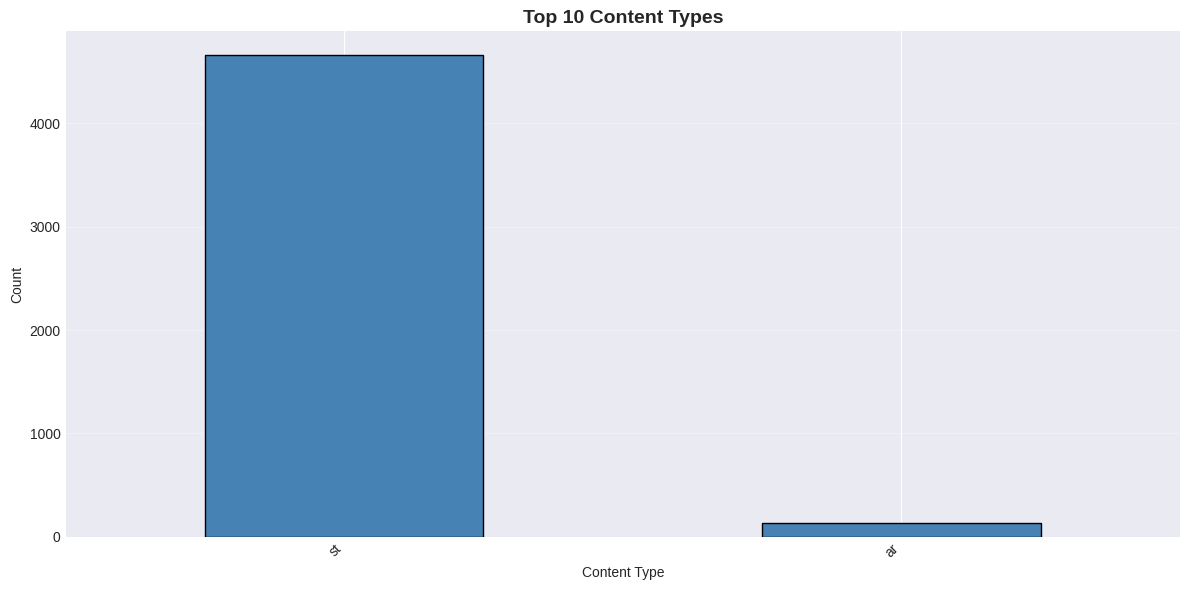

In [15]:
# Analyze most common content types
print("=" * 80)
print("CONTENT TYPE DISTRIBUTION")
print("=" * 80)

type_counts = df['type'].value_counts()
print(f"\nContent types found: {df['type'].nunique()}")
print("\nDistribution:")
print(type_counts)

# Visualize
plt.figure(figsize=(12, 6))
type_counts.head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Content Types', fontsize=14, fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

LANGUAGE DISTRIBUTION

Languages found: 11

Top 10 languages:
language
es       4698
es-es      48
es-co      38
es-mx       3
es-pe       2
es-ve       1
es-hn       1
es-gt       1
es-ar       1
es-ec       1
Name: count, dtype: int64


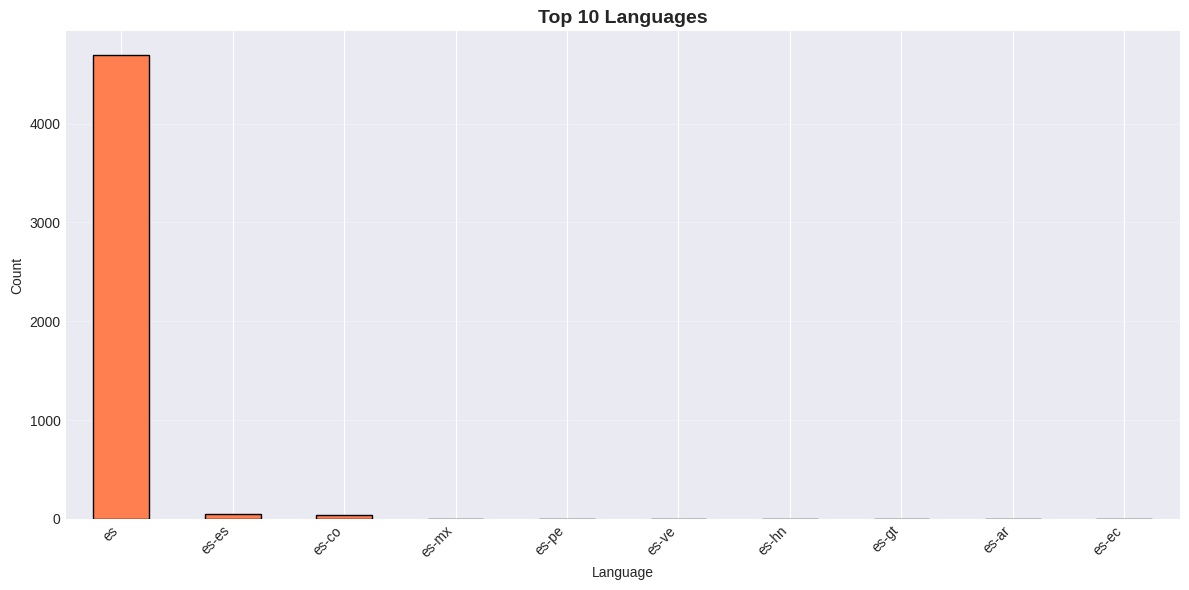

In [16]:
# Analyze languages
print("=" * 80)
print("LANGUAGE DISTRIBUTION")
print("=" * 80)

language_counts = df['language'].value_counts()
print(f"\nLanguages found: {df['language'].nunique()}")
print(f"\nTop 10 languages:")
print(language_counts.head(10))

# Visualize
plt.figure(figsize=(12, 6))
language_counts.head(10).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 Languages', fontsize=14, fontweight='bold')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

TOP AUTHORS ANALYSIS

Total unique authors: 3395
Posts without author: 468

Top 15 most active authors:
author
Merryluz777 (@merryluz7771)        20
vlakho (@vlakho731)                17
Martha ⭐ (@marthalestrella6)       17
marcepoboo (@marcepiboo)           17
maso (@maso8014)                   15
tahilis19 (@tahilis19)             14
Stev_G. A. (@stev_g.a)             12
Pinkiri Gaymer (@pinkirigaymer)    12
seba (@sebastian658322)            12
Grok (@grok)                       12
Berenice (@bery27277)              11
Rudy Stella (@rubyluna7)           10
Steffy Gomez (@steffygomez81)      10
ey cesar (@eycesar_77)             10
Katie G (@katie.g59)               10
Name: count, dtype: int64


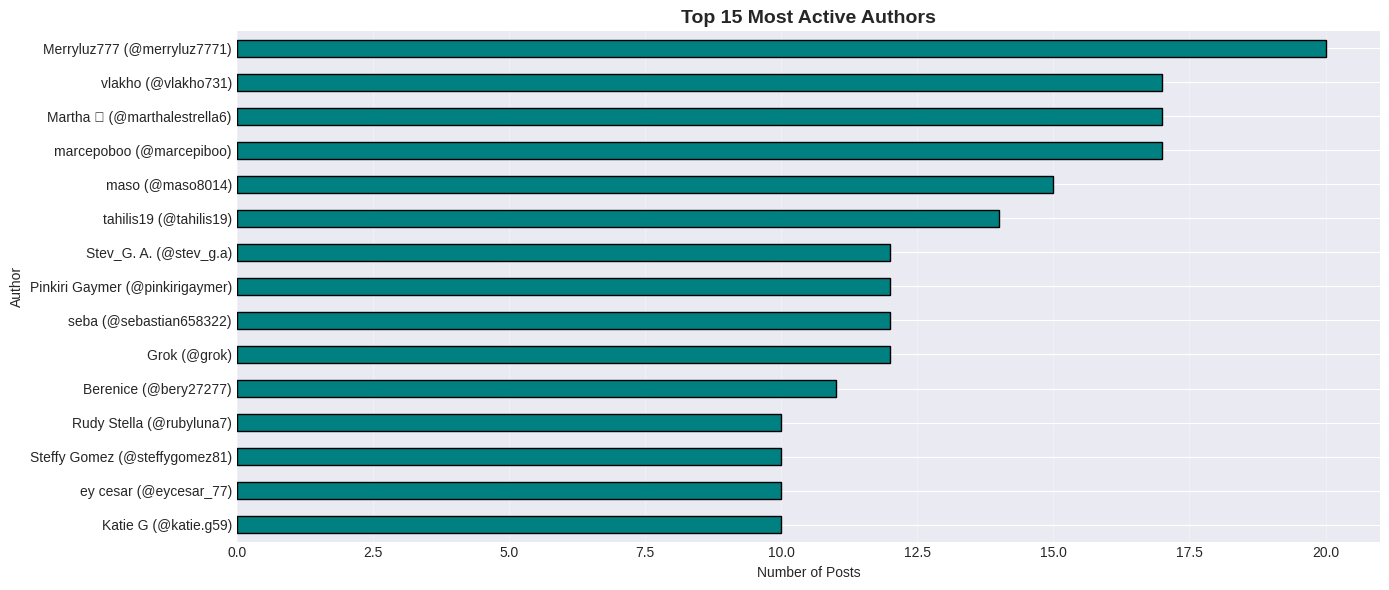

In [17]:
# Analyze top authors
print("=" * 80)
print("TOP AUTHORS ANALYSIS")
print("=" * 80)

# Filter out empty authors
authors_filtered = df[df['author'].str.strip() != '']['author']
author_counts = authors_filtered.value_counts()

print(f"\nTotal unique authors: {len(author_counts)}")
print(f"Posts without author: {(df['author'].str.strip() == '').sum()}")
print(f"\nTop 15 most active authors:")
print(author_counts.head(15))

# Visualize
plt.figure(figsize=(14, 6))
author_counts.head(15).plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 15 Most Active Authors', fontsize=14, fontweight='bold')
plt.xlabel('Number of Posts')
plt.ylabel('Author')
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

TEXT CONTENT LENGTH ANALYSIS

Text Length Statistics:
  Mean: 301.09 characters
  Median: 56.00 characters
  Min: 1 characters
  Max: 27649 characters

Title Length Statistics:
  Mean: 104.93 characters
  Median: 105.00 characters
  Min: 21 characters
  Max: 190 characters


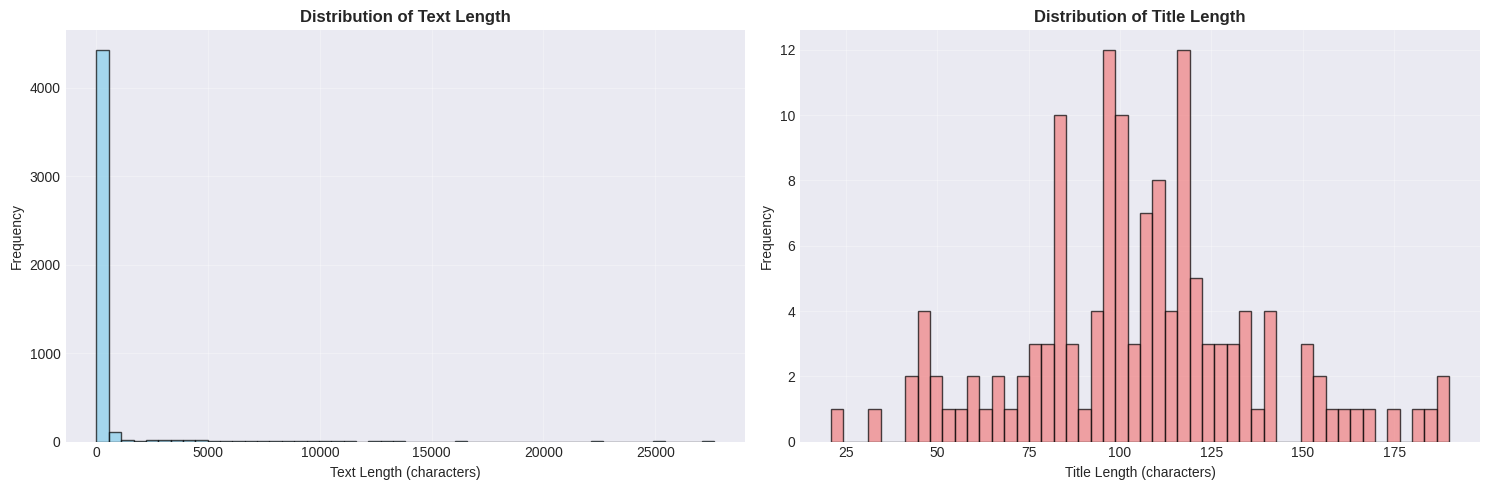

In [18]:
# Analyze text content length
print("=" * 80)
print("TEXT CONTENT LENGTH ANALYSIS")
print("=" * 80)

# Calculate text length for non-empty texts
df['text_length'] = df['text'].str.len()
df['title_length'] = df['title'].str.len()

# Filter out empty texts
text_lengths = df[df['text_length'] > 0]['text_length']
title_lengths = df[df['title_length'] > 0]['title_length']

print(f"\nText Length Statistics:")
print(f"  Mean: {text_lengths.mean():.2f} characters")
print(f"  Median: {text_lengths.median():.2f} characters")
print(f"  Min: {text_lengths.min()} characters")
print(f"  Max: {text_lengths.max()} characters")

print(f"\nTitle Length Statistics:")
print(f"  Mean: {title_lengths.mean():.2f} characters")
print(f"  Median: {title_lengths.median():.2f} characters")
print(f"  Min: {title_lengths.min()} characters")
print(f"  Max: {title_lengths.max()} characters")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(text_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Text Length', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(title_lengths, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Title Length', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Title Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TOP NEWS SOURCES ANALYSIS

Total unique sources: 34
Posts without source: 4393

Top 15 most common sources:
sourceName
Noticias Caracol                           197
Blu Radio                                  130
Presidencia de la República de Colombia     11
El Tiempo                                    9
Caracol Radio                                4
LU17.com                                     4
Valora Analitik                              4
Revista Semana                               4
Gustavo Petro                                3
Publimetro Colombia                          3
El Espectador                                3
Infobae Colombia                             2
Portafolio                                   2
RED+ Noticias                                2
La FM                                        2
Name: count, dtype: int64


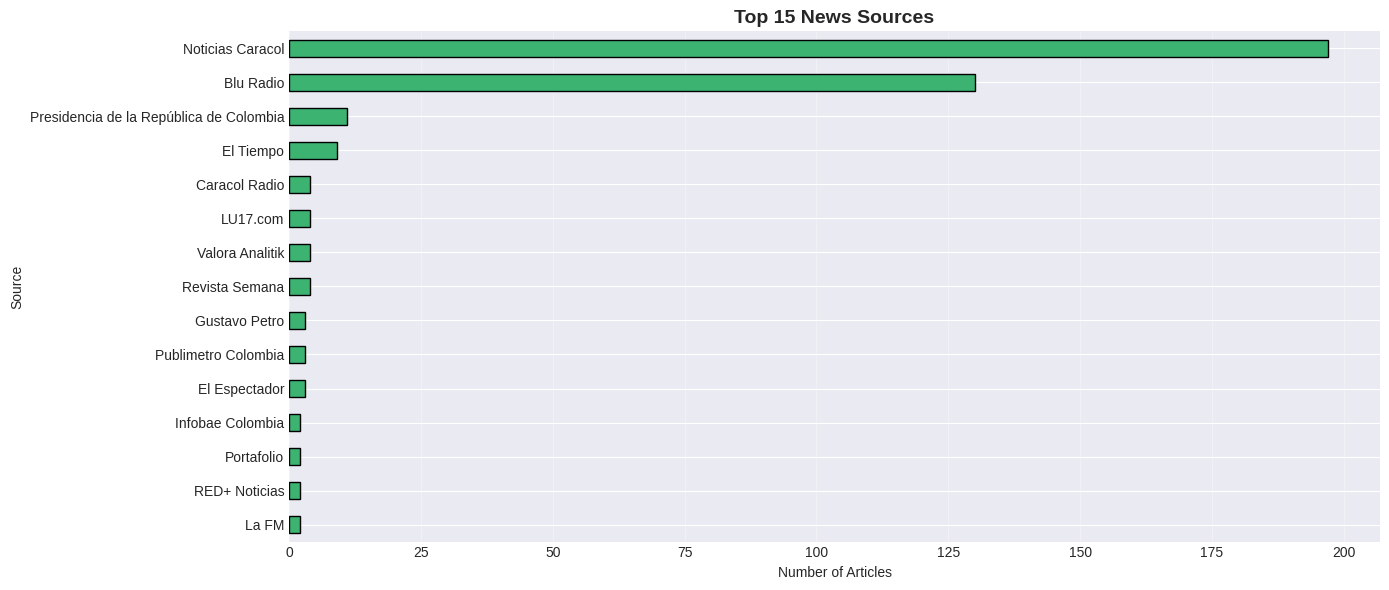

In [19]:
# Analyze top sources
print("=" * 80)
print("TOP NEWS SOURCES ANALYSIS")
print("=" * 80)

# Filter out empty sources
sources_filtered = df[df['sourceName'].str.strip() != '']['sourceName']
source_counts = sources_filtered.value_counts()

print(f"\nTotal unique sources: {len(source_counts)}")
print(f"Posts without source: {(df['sourceName'].str.strip() == '').sum()}")
print(f"\nTop 15 most common sources:")
print(source_counts.head(15))

# Visualize
plt.figure(figsize=(14, 6))
source_counts.head(15).plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Top 15 News Sources', fontsize=14, fontweight='bold')
plt.xlabel('Number of Articles')
plt.ylabel('Source')
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Boolean Fields Analysis

BOOLEAN FIELDS DISTRIBUTION


,Field,Unique_Values,Most_Common,Count
0,isBot,1,False,4795
1,isComment,2,True,4567
2,isRetweet,1,False,4795
3,isDeleted,1,False,4795
4,isHidden,1,False,4795
5,isRead,2,False,4753
6,isReplied,1,False,4795
7,isAdvertisement,1,False,4795
8,isArchived,1,False,4795


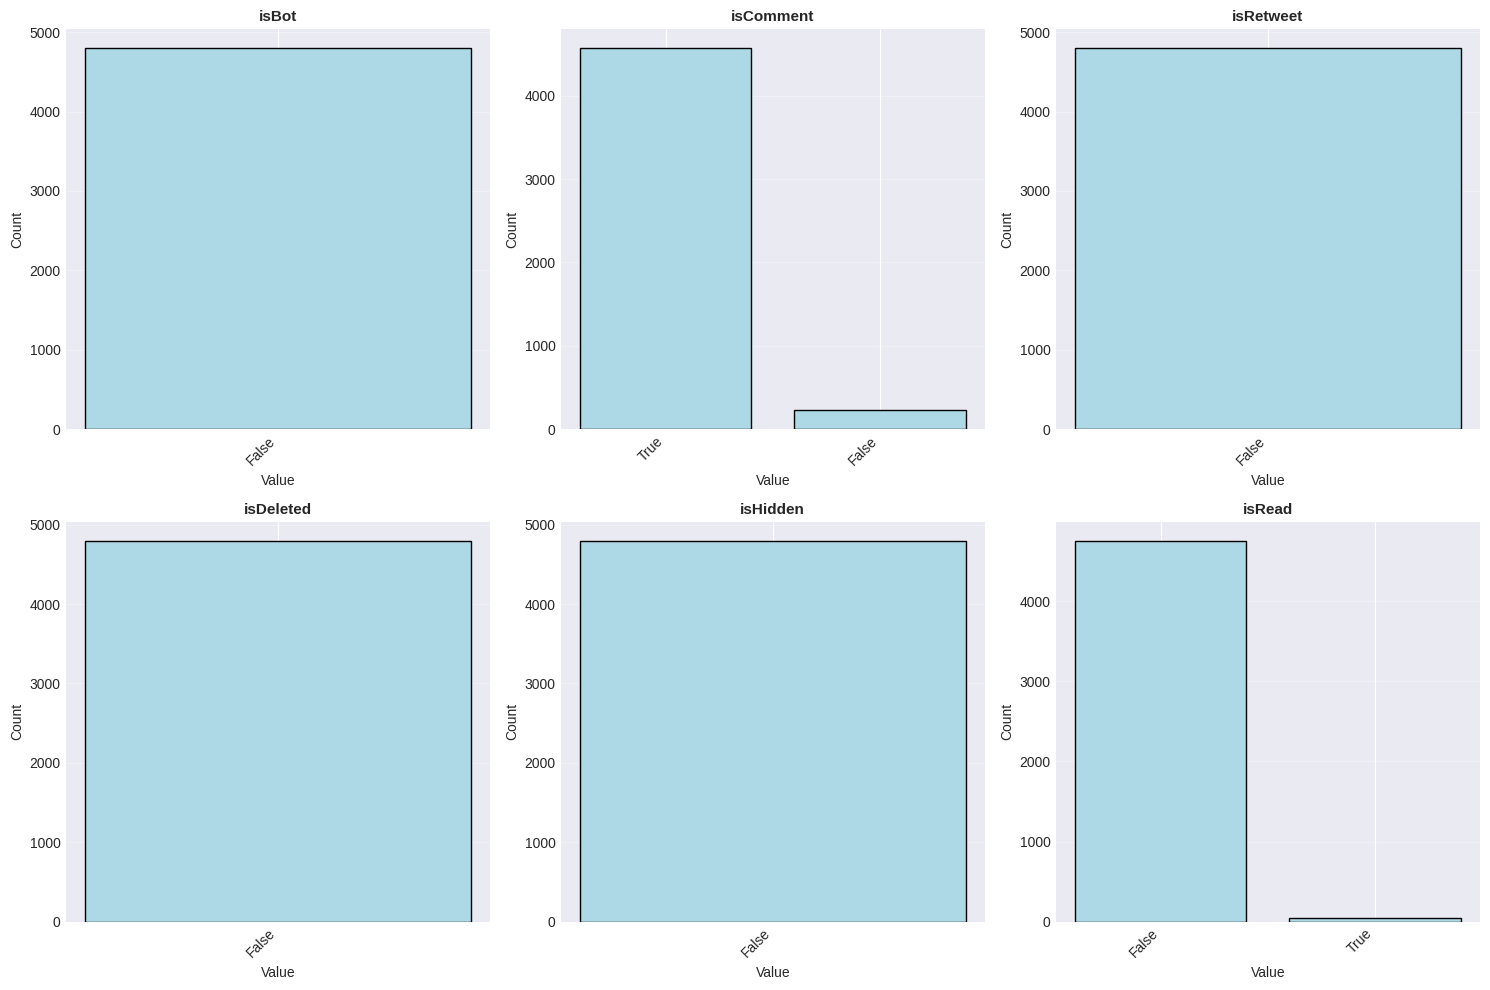

In [20]:
# Analyze boolean-like fields
print("=" * 80)
print("BOOLEAN FIELDS DISTRIBUTION")
print("=" * 80)

boolean_cols = ['isBot', 'isComment', 'isRetweet', 'isDeleted', 'isHidden', 
                'isRead', 'isReplied', 'isAdvertisement', 'isArchived']

boolean_stats = []
for col in boolean_cols:
    if col in df.columns:
        value_counts = df[col].value_counts()
        boolean_stats.append({
            'Field': col,
            'Unique_Values': df[col].nunique(),
            'Most_Common': value_counts.index[0] if len(value_counts) > 0 else 'N/A',
            'Count': value_counts.values[0] if len(value_counts) > 0 else 0
        })

boolean_df = pd.DataFrame(boolean_stats)
display(boolean_df)

# Visualize a subset
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(boolean_cols[:6]):
    if col in df.columns:
        value_counts = df[col].value_counts().head(5)
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='lightblue', edgecolor='black')
        axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Count')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()